In [109]:
import pandas as pd

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/regression/logistic_regression/synthetic_churn_data.csv")
print(f"Dataset shape: {df.shape}")
df.head()


# df.to_csv("../../lab/python/data/regression/logistic_regression/synthetic_churn_data.csv", index=False)

Dataset shape: (1000, 6)


,tenure,monthly_charges,support_calls,contract_type,churn,education_level
0,29,46.867736,6,0,0,High School
1,15,74.163421,6,0,0,Bachelor
2,8,83.347822,3,1,0,Master
3,21,45.788769,2,0,0,High School
4,19,33.935607,7,0,1,Master


In [110]:
print(df.columns)
df.info()

Index(['tenure', 'monthly_charges', 'support_calls', 'contract_type', 'churn',
       'education_level'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           1000 non-null   int64  
 1   monthly_charges  1000 non-null   float64
 2   support_calls    1000 non-null   int64  
 3   contract_type    1000 non-null   int64  
 4   churn            1000 non-null   int64  
 5   education_level  1000 non-null   str    
dtypes: float64(1), int64(4), str(1)
memory usage: 53.8 KB


In [111]:
df['churn'].value_counts(normalize=True)

churn
0    0.633
1    0.367
Name: proportion, dtype: float64

In [112]:
churn_rate_by_contract = df.groupby('contract_type')['churn'].mean().reset_index()
import plotly.express as px
fig = px.bar(churn_rate_by_contract, x='contract_type', y='churn', title='Churn Rate by Contract Type')
fig.update_layout(
    xaxis_title='Contract Type (0 = Prepaid, 1 = Postpaid)',
    yaxis_title='Churn Rate',
    template='plotly_white'
)   
fig.show()

In [113]:
X = df.drop(columns=["churn"])
y = df["churn"]

In [114]:
education_order = ["High School", "Bachelor", "Master", "PhD"]

df["education_level"] = pd.Categorical(
    df["education_level"],
    categories=education_order,
    ordered=True
)

education_dummies = pd.get_dummies(
    df["education_level"],
    prefix="education",
    drop_first=True,
    dtype=int
)

education_dummies.head()

,education_Bachelor,education_Master,education_PhD
0,0,0,0
1,1,0,0
2,0,1,0
3,0,0,0
4,0,1,0


In [115]:
X_encoded = pd.concat([X.drop(columns=["education_level"]), education_dummies], axis=1)

X_encoded.head()

,tenure,monthly_charges,support_calls,contract_type,education_Bachelor,education_Master,education_PhD
0,29,46.867736,6,0,0,0,0
1,15,74.163421,6,0,1,0,0
2,8,83.347822,3,1,0,1,0
3,21,45.788769,2,0,0,0,0
4,19,33.935607,7,0,0,1,0


In [116]:
print("Final set of features:")
print(X_encoded.dtypes)

Final set of features:
tenure                  int64
monthly_charges       float64
support_calls           int64
contract_type           int64
education_Bachelor      int64
education_Master        int64
education_PhD           int64
dtype: object


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [118]:
X_train, X_test, y_train, y_test

(     tenure  monthly_charges  support_calls  contract_type  \
 494      32        51.615610              6              0   
 687      26        52.433375              5              0   
 720      31        32.771348              2              0   
 381      33       100.172808              0              0   
 3        21        45.788769              2              0   
 ..      ...              ...            ...            ...   
 139      24        93.758230              8              1   
 565       3        57.325179              4              1   
 503      14       106.791829              9              0   
 759      20       106.201448              0              1   
 551      22        96.228513              0              0   
 
      education_Bachelor  education_Master  education_PhD  
 494                   1                 0              0  
 687                   0                 0              0  
 720                   1                 0              0  
 3

In [119]:
train_size = len(X_train)
test_size = len(X_test)

train_churn_rate = y_train.mean()
test_churn_rate = y_test.mean()

print("Training rows:", train_size)
print("Test rows:", test_size)
print("Training churn rate:", round(train_churn_rate, 3))
print("Test churn rate:", round(test_churn_rate, 3))

Training rows: 800
Test rows: 200
Training churn rate: 0.368
Test churn rate: 0.365


In [120]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [121]:
probs = model.predict_proba(X_test)
probs[:5]

array([[0.98318892, 0.01681108],
       [0.58272399, 0.41727601],
       [0.52510946, 0.47489054],
       [0.38401511, 0.61598489],
       [0.67937155, 0.32062845]])

In [122]:
probs = probs[:, 1]
probs[:5]

array([0.01681108, 0.41727601, 0.47489054, 0.61598489, 0.32062845])

In [123]:
threshold = 0.5
preds = (probs >= threshold).astype(int)
preds[:5]

array([0, 0, 0, 1, 0])

In [124]:
prediction_results = X_test.copy()

prediction_results["actual_churn"] = y_test.values
prediction_results["predicted_probability"] = probs
prediction_results["predicted_churn"] = preds

prediction_results.head()

,tenure,monthly_charges,support_calls,contract_type,education_Bachelor,education_Master,education_PhD,actual_churn,predicted_probability,predicted_churn
361,34,55.062693,2,1,0,0,0,0,0.016811,0
5,23,103.493024,4,0,0,0,1,0,0.417276,0
692,25,75.778342,5,0,0,1,0,1,0.474891,0
708,6,112.717782,5,1,0,1,0,0,0.615985,1
841,26,67.601813,7,1,0,0,1,0,0.320628,0


### Coefficient Interpretation with Exponentiated Betas
#### The raw coefficients are log-odds coefficients.
#### To make them easier to interpret, we exponentiate them.

In [125]:
coef_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "beta": model.coef_[0],
    "exp_beta": np.exp(model.coef_[0])
})

coef_df = coef_df.sort_values("exp_beta", ascending=False)

coef_df

,feature,beta,exp_beta
2,support_calls,0.569345,1.767109
4,education_Bachelor,0.122864,1.130731
5,education_Master,0.112275,1.118820
1,monthly_charges,0.020345,1.020553
0,tenure,-0.055286,0.946214
6,education_PhD,-0.226242,0.797525
3,contract_type,-1.228900,0.292614


## Confusion Matrix

In [126]:
cm = confusion_matrix(y_test, preds)

tn, fp, fn, tp = cm.ravel()

cm

array([[103,  24],
       [ 23,  50]])

In [127]:
# Classification metrics
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3)) # This means that among customers predicted as churners, 67.57% actually churned
print("Recall:", round(recall, 3)) # This means that among all actual churners, the model identified 68.49%.

Accuracy: 0.765
Precision: 0.676
Recall: 0.685


## ROC Curve and AUC

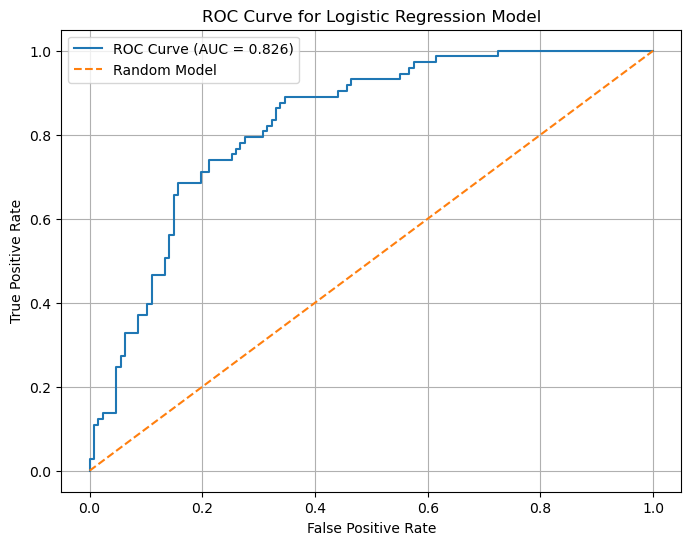

In [128]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probs)

auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.show()

### Threshold Table from ROC Curve

#### The ROC curve gives many possible thresholds.

#### We can inspect some of them:

In [129]:
roc_threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "false_positive_rate": fpr,
    "true_positive_rate": tpr
})

roc_threshold_table.head(10)

,threshold,false_positive_rate,true_positive_rate
0,inf,0.000000,0.000000
1,0.942002,0.000000,0.013699
2,0.918466,0.000000,0.027397
3,0.914075,0.007874,0.027397
4,0.872712,0.007874,0.109589
5,0.865494,0.015748,0.109589
6,0.864793,0.015748,0.123288
7,0.863048,0.023622,0.123288
8,0.856350,0.023622,0.136986
9,0.836167,0.047244,0.136986


#### Revenue impact analysis

In [130]:
retention_cost = 10
retention_benefit = 50

revenue_from_saved_customers = tp * (retention_benefit - retention_cost)
cost_from_unnecessary_contacts = fp * retention_cost

net_profit = revenue_from_saved_customers - cost_from_unnecessary_contacts

print("Revenue from saved customers:", revenue_from_saved_customers)
print("Cost from unnecessary contacts:", cost_from_unnecessary_contacts)
print("Net profit:", net_profit)

Revenue from saved customers: 2000
Cost from unnecessary contacts: 240
Net profit: 1760


# Customer Churn Prediction (own)

In [131]:
df = pd.read_csv("https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/regression/logistic_regression/Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [132]:
df.isna().sum()
print(df.columns)
print(df.info())

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   Onli

In [133]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [134]:
df['Contract'].dtype
df['MonthlyCharges'].dtype
df['Contract'].value_counts()


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [135]:
df= df.replace({'Yes': 1, 'No': 0})
df_shrinked = df[["SeniorCitizen", "tenure", "Contract", "MonthlyCharges", "Churn"]].copy()
df_shrinked.head()

,SeniorCitizen,tenure,Contract,MonthlyCharges,Churn
0,0,1,Month-to-month,29.85,0
1,0,34,One year,56.95,0
2,0,2,Month-to-month,53.85,1
3,0,45,One year,42.30,0
4,0,2,Month-to-month,70.70,1


In [136]:

X = df_shrinked.drop(columns=["Churn"])
y = df_shrinked["Churn"]

In [137]:
df["Contract"] = df["Contract"].replace({"Month-to-month": 0, "One year": 1, "Two year": 2})
df_dummies = pd.get_dummies(
    df["Contract"], 
    prefix="Contract",
    drop_first=True, 
    dtype=int)

print(df_dummies.head())

   Contract_1  Contract_2
0           0           0
1           1           0
2           0           0
3           1           0
4           0           0


In [138]:
X_encoded = pd.concat([X.drop(columns=["Contract"]), df_dummies], axis=1)
print(X_encoded.head())
print(X_encoded.info())

   SeniorCitizen  tenure  MonthlyCharges  Contract_1  Contract_2
0              0       1           29.85           0           0
1              0      34           56.95           1           0
2              0       2           53.85           0           0
3              0      45           42.30           1           0
4              0       2           70.70           0           0
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SeniorCitizen   7043 non-null   int64  
 1   tenure          7043 non-null   int64  
 2   MonthlyCharges  7043 non-null   float64
 3   Contract_1      7043 non-null   int64  
 4   Contract_2      7043 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 275.2 KB
None


In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_test, y_train, y_test

(      SeniorCitizen  tenure  MonthlyCharges  Contract_1  Contract_2
 3738              0      35           49.20           0           0
 3151              0      15           75.10           0           0
 4860              0      13           40.55           0           1
 3867              0      26           73.50           0           1
 3810              0       1           44.55           0           0
 ...             ...     ...             ...         ...         ...
 6303              0      71          109.25           0           1
 6227              0       2           46.05           0           0
 4673              1      25          102.80           0           0
 2710              0      24           20.40           1           0
 5639              0       6           20.65           0           0
 
 [5634 rows x 5 columns],
       SeniorCitizen  tenure  MonthlyCharges  Contract_1  Contract_2
 437               0      72          114.05           0           1
 2280 

In [140]:
train_size = len(X_train)
test_size = len(X_test)

train_churn_rate = y_train.mean()
test_churn_rate = y_test.mean()

print("Training rows:", train_size)
print("Test rows:", test_size)
print("Training churn rate:", round(train_churn_rate, 3))
print("Test churn rate:", round(test_churn_rate, 3))

Training rows: 5634
Test rows: 1409
Training churn rate: 0.265
Test churn rate: 0.265


In [141]:
y_train.value_counts(normalize=True)

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [144]:

y_train = y_train.astype(int)

churn_model = LogisticRegression(max_iter=1000)

churn_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [158]:
probs = churn_model.predict_proba(X_test)
probs[:5]

array([[0.94982351, 0.05017649],
       [0.21775476, 0.78224524],
       [0.87618202, 0.12381798],
       [0.52562043, 0.47437957],
       [0.97857815, 0.02142185]])

In [159]:
probs = probs[:, 1]
probs[:5]

array([0.05017649, 0.78224524, 0.12381798, 0.47437957, 0.02142185])

In [160]:
threshold = 0.5
preds = (probs >= threshold).astype(int)
preds[:5]

array([0, 1, 0, 0, 0])

In [161]:
prediction_results = X_test.copy()

prediction_results["actual_churn"] = y_test.values
prediction_results["predicted_probability"] = probs
prediction_results["predicted_churn"] = preds

prediction_results.head()

,SeniorCitizen,tenure,MonthlyCharges,Contract_1,Contract_2,actual_churn,predicted_probability,predicted_churn
437,0,72,114.05,0,1,0,0.050176,0
2280,1,8,100.15,0,0,0,0.782245,1
2235,0,41,78.35,1,0,0,0.123818,0
4460,0,18,78.20,0,0,0,0.474380,0
3761,0,72,82.65,0,1,0,0.021422,0


In [163]:
coef_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "beta": churn_model.coef_[0],
    "exp_beta": np.exp(churn_model.coef_[0])
})

coef_df = coef_df.sort_values("exp_beta", ascending=False)

coef_df

,feature,beta,exp_beta
0,SeniorCitizen,0.406433,1.501453
2,MonthlyCharges,0.028056,1.028453
1,tenure,-0.035911,0.964726
3,Contract_1,-1.032452,0.356133
4,Contract_2,-1.904789,0.148854


In [165]:

y_test = y_test.astype(int)
cm = confusion_matrix(y_test, preds)

tn, fp, fn, tp = cm.ravel()

cm

array([[925, 110],
       [190, 184]])

In [166]:
# Classification metrics
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3)) # This means that among customers predicted as churners, 67.57% actually churned
print("Recall:", round(recall, 3)) # This means that among all actual churners, the model identified 68.49%.

Accuracy: 0.787
Precision: 0.626
Recall: 0.492


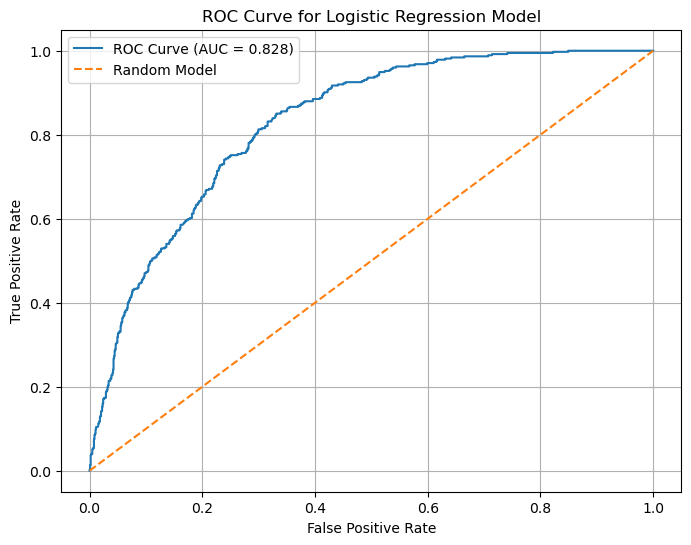

In [167]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probs)

auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.show()

In [170]:
roc_threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "false_positive_rate": fpr,
    "true_positive_rate": tpr
})

roc_threshold_table.head(10)

,threshold,false_positive_rate,true_positive_rate
0,inf,0.000000,0.000000
1,0.834750,0.000000,0.002674
2,0.815582,0.000966,0.002674
3,0.784056,0.000966,0.013369
4,0.782245,0.001932,0.013369
5,0.745426,0.001932,0.037433
6,0.739344,0.002899,0.037433
7,0.737068,0.002899,0.040107
8,0.732255,0.004831,0.040107
9,0.723926,0.004831,0.050802


In [171]:
retention_cost = 12
retention_benefit = 55

revenue_from_saved_customers = tp * (retention_benefit - retention_cost)
cost_from_unnecessary_contacts = fp * retention_cost

net_profit = revenue_from_saved_customers - cost_from_unnecessary_contacts

print("Revenue from saved customers:", revenue_from_saved_customers)
print("Cost from unnecessary contacts:", cost_from_unnecessary_contacts)
print("Net profit:", net_profit)

Revenue from saved customers: 7912
Cost from unnecessary contacts: 1320
Net profit: 6592
